# Retail Market Basket Intelligence: Phase 3 - Association Rule Mining

**Author:** Karthik Yelugam | Data Analyst  
**Environment:** Python, Pandas, mlxtend, NetworkX, Matplotlib, Seaborn  

### 📌 Executive Summary & Phase Objective
This notebook represents **Phase 3** (the final analytical phase) of the Market Basket Intelligence pipeline. Using the sparse boolean matrix generated in Phase 2, we deploy the **Apriori Algorithm** to extract frequent itemsets and generate actionable association rules.

**Key Operations Performed:**
1. **Frequent Itemset Generation:** Identifying product combinations that meet a strict minimum support threshold (0.02).
2. **Association Rule Mining:** Calculating Confidence and Lift to determine the strength and reliability of product relationships.
3. **Comprehensive Visualization:** Generating business-ready charts (Bar Charts, Scatter Plots, Histograms, and Network Graphs) to present mathematical findings.
4. **Strategic Filtering:** Isolating high-impact rules (Lift > 1.2, Confidence >= 0.3) to drive cross-selling and bundling strategies.

**Output:** Actionable retail recommendations based on mathematical product associations.

In [1]:
# =============================================================================
# 0. IMPORT REQUIRED LIBRARIES & CONFIGURE SETTINGS
# =============================================================================

import pandas as pd
import numpy as np
import warnings

# Machine Learning & Association Rules
from mlxtend.frequent_patterns import apriori, association_rules

# Advanced Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Global Display & Warning Settings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Enterprise Visualization Theme
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid", palette="muted")

print("✔ All libraries loaded and environment configured successfully.")

✔ All libraries loaded and environment configured successfully.


---
## 1. Load Preprocessed Basket Matrix
We begin by ingesting the `apriori_dataset.csv` generated in Phase 2. This dataset is a highly optimized binary matrix where rows represent unique transactions and columns represent high-frequency products.

In [2]:
# =============================================================================
# 1.1 INGEST APRIORI DATASET
# =============================================================================

print("Loading basket matrix... Please wait.")

# Load the dataset, using the first column as the index (BillNo)
file_path = "data/processed/apriori_dataset.csv"

try:
    basket_matrix = pd.read_csv(file_path, index_col=0)
    
    print(f"✔ Basket Matrix successfully loaded!")
    print(f"  Total Transactions (Rows): {basket_matrix.shape[0]:,}")
    print(f"  Total Products (Columns):  {basket_matrix.shape[1]:,}")
    
except FileNotFoundError:
    print(f"❌ Error: File not found at '{file_path}'. Please ensure Phase 2 was completed successfully.")

Loading basket matrix... Please wait.
✔ Basket Matrix successfully loaded!
  Total Transactions (Rows): 17,597
  Total Products (Columns):  1,295


---
## 2. Frequent Itemset Generation (Apriori Algorithm)
The Apriori algorithm scans the matrix to find product combinations that occur together frequently. We apply a minimum support threshold of 0.02 (the itemset must appear in at least 2% of all transactions) to filter out rare occurrences.

In [3]:
# =============================================================================
# 2.1 EXTRACT FREQUENT ITEMSETS
# =============================================================================

MIN_SUPPORT = 0.02
print(f"Executing Apriori Algorithm with min_support = {MIN_SUPPORT}...")

# Convert matrix to boolean to comply with the latest mlxtend standards and improve performance
basket_matrix_bool = basket_matrix.astype(bool)

# Run Apriori
frequent_itemsets = apriori(basket_matrix_bool, min_support=MIN_SUPPORT, use_colnames=True)

# Add itemset length for analytical filtering
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Sort by support to identify the most popular combinations
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).reset_index(drop=True)

print(f"✔ Frequent Itemsets generated! Found {len(frequent_itemsets)} itemsets.")
display(frequent_itemsets.head(10))

Executing Apriori Algorithm with min_support = 0.02...
✔ Frequent Itemsets generated! Found 347 itemsets.


,support,itemsets,itemset_length
0,0.1041,(WHITE HANGING HEART T-LIGHT HOLDER),1
1,0.1005,(JUMBO BAG RED RETROSPOT),1
2,0.0801,(LUNCH BAG RED RETROSPOT),1
3,0.0720,(PARTY BUNTING),1
4,0.0682,(LUNCH BAG BLACK SKULL.),1
5,0.0669,(NATURAL SLATE HEART CHALKBOARD),1
6,0.0630,(LUNCH BAG SPACEBOY DESIGN),1
7,0.0623,(JUMBO BAG PINK POLKADOT),1
8,0.0623,(JUMBO STORAGE BAG SUKI),1
9,0.0622,(JUMBO SHOPPER VINTAGE RED PAISLEY),1


---
## 3. Visualizing Top Frequent Products
Before analyzing complex rules, we must understand the baseline popularity of individual items.

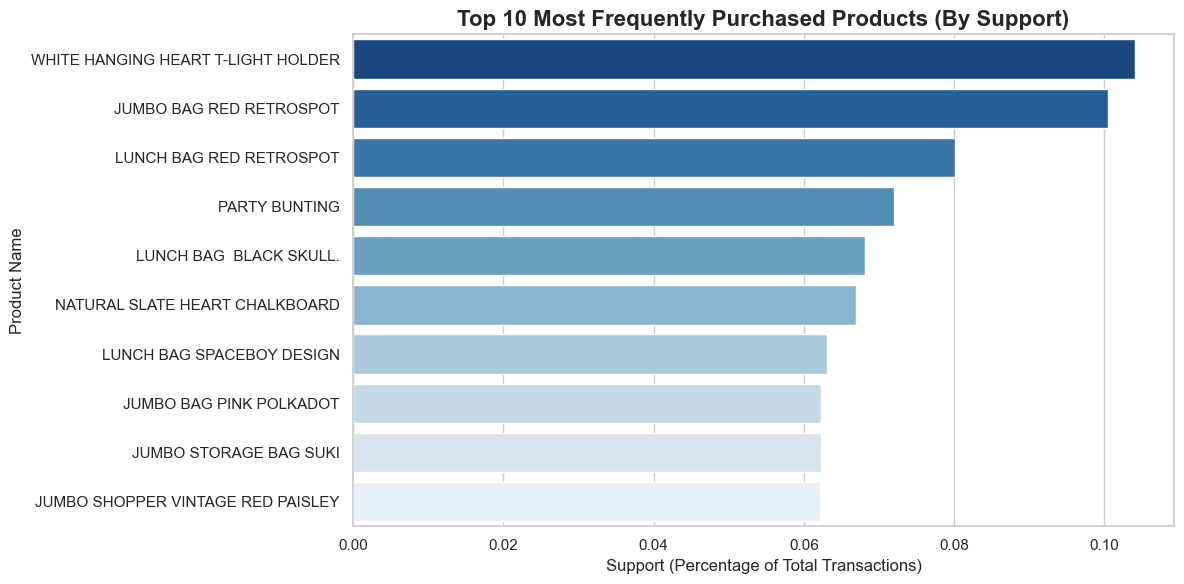

In [4]:
# =============================================================================
# 3.1 BAR CHART: TOP 10 FREQUENTLY PURCHASED PRODUCTS
# =============================================================================

# Isolate single-item sets for baseline product popularity
single_items = frequent_itemsets[frequent_itemsets['itemset_length'] == 1].head(10)
# Extract the string name from the frozenset
single_items['product_name'] = single_items['itemsets'].apply(lambda x: list(x)[0])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=single_items, 
    x='support', 
    y='product_name', 
    hue='product_name',
    palette='Blues_r', 
    legend=False
)

plt.title("Top 10 Most Frequently Purchased Products (By Support)", fontsize=16, fontweight="bold")
plt.xlabel("Support (Percentage of Total Transactions)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Association Rule Mining
We evaluate product relationships using three core metrics:
* **Support:** How often the rule occurs in the overall dataset.
* **Confidence:** The probability of finding the consequent product in a transaction given that it contains the antecedent product.
* **Lift:** The ratio of observed support to expected support. A Lift > 1 indicates a strong positive association.

In [5]:
# =============================================================================
# 4.1 GENERATE AND FILTER ASSOCIATION RULES
# =============================================================================

print("Generating Association Rules...")

# Generate baseline rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Filter for highly actionable business rules (Strong Lift & Reliable Confidence)
strong_rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] >= 0.3)]

# Sort by Lift (highest impact) and Confidence (highest probability)
strong_rules = strong_rules.sort_values(by=['lift', 'confidence'], ascending=[False, False]).reset_index(drop=True)

# Format the antecedents and consequents from frozensets to clean strings for professional display
strong_rules['antecedents'] = strong_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
strong_rules['consequents'] = strong_rules['consequents'].apply(lambda x: ', '.join(list(x)))
strong_rules['rule_name'] = strong_rules['antecedents'] + "  →  " + strong_rules['consequents']

print(f"✔ Association Rules generated! Found {len(strong_rules)} strong, actionable rules.")
display(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Generating Association Rules...
✔ Association Rules generated! Found 142 strong, actionable rules.


,antecedents,consequents,support,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.0262,0.6850,18.3467
1,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.0262,0.7017,18.3467
2,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.0262,0.9004,17.7426
3,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.0262,0.5162,17.7426
4,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.0262,0.8367,16.1433
5,ROSES REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",0.0262,0.5055,16.1433
6,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0313,0.8187,16.1333
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0313,0.6170,16.1333
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.0281,0.7007,15.0370
9,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.0281,0.6024,15.0370


---
## 5. Visualizing Association Rules
To effectively communicate these mathematical findings to business stakeholders, we translate the rules into intuitive visual dashboards.

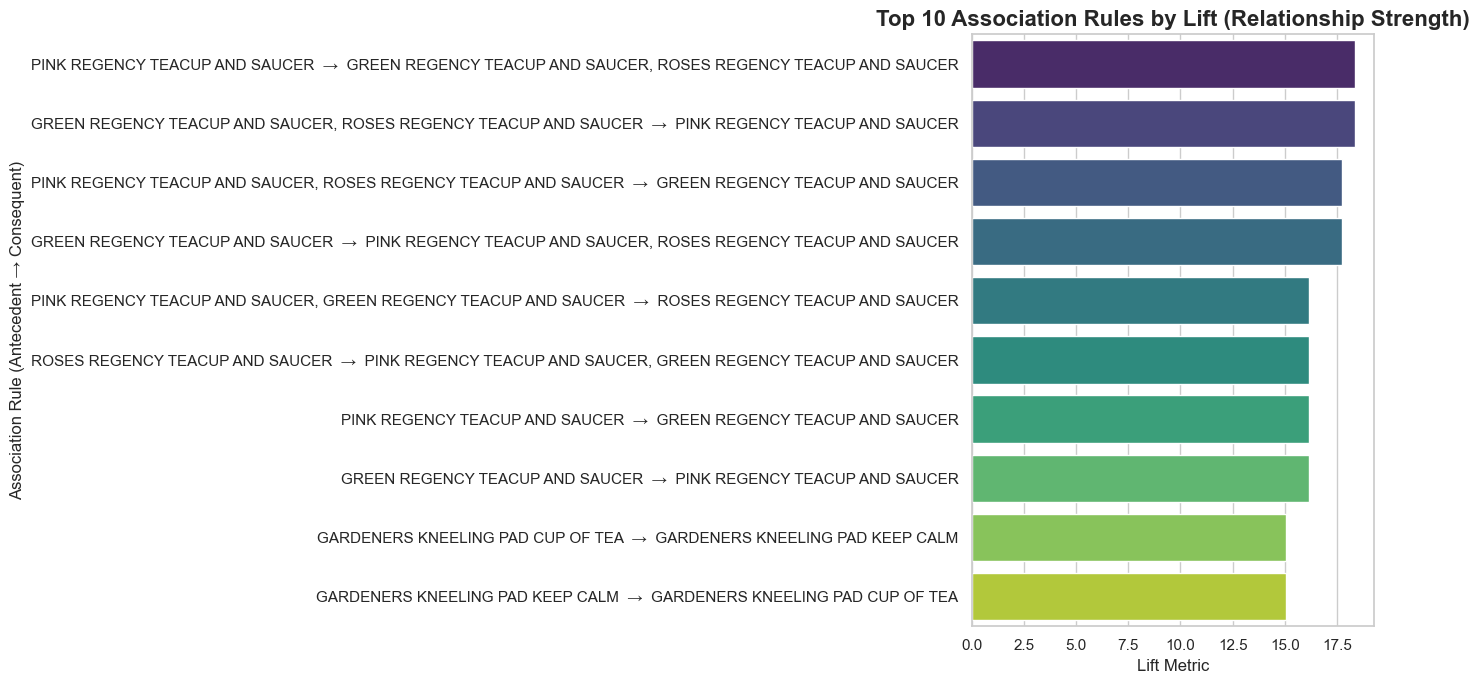

In [6]:
# =============================================================================
# 5.1 BAR CHART: TOP 10 ASSOCIATION RULES BY LIFT
# =============================================================================

top_10_lift_rules = strong_rules.head(10)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_10_lift_rules, 
    x='lift', 
    y='rule_name', 
    hue='rule_name',
    palette='viridis', 
    legend=False
)

plt.title("Top 10 Association Rules by Lift (Relationship Strength)", fontsize=16, fontweight="bold")
plt.xlabel("Lift Metric", fontsize=12)
plt.ylabel("Association Rule (Antecedent → Consequent)", fontsize=12)
plt.tight_layout()
plt.show()

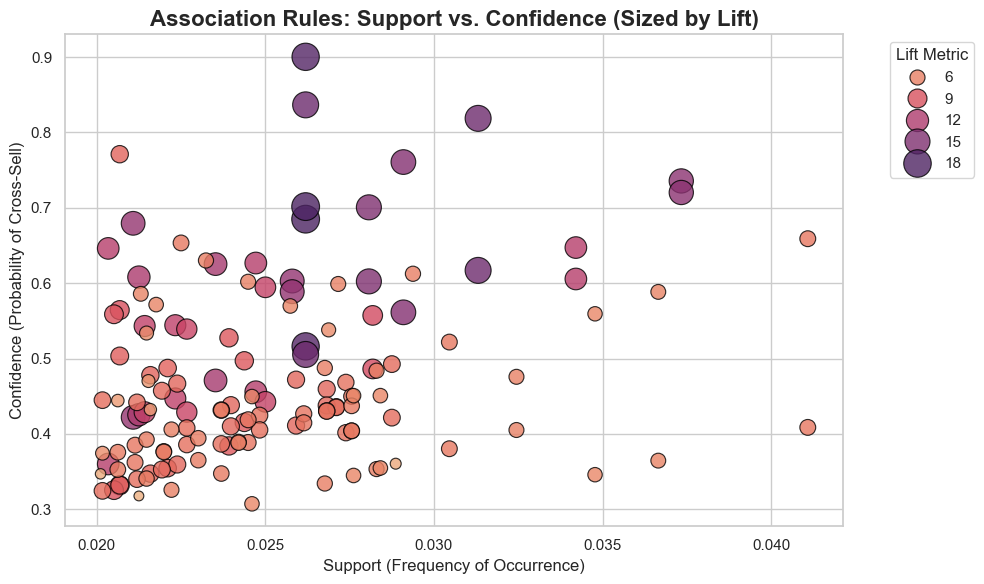

In [7]:
# =============================================================================
# 5.2 SCATTER PLOT: SUPPORT VS. CONFIDENCE
# =============================================================================

plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=strong_rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    sizes=(50, 400),
    palette="flare",
    alpha=0.8,
    edgecolor="black"
)

plt.title("Association Rules: Support vs. Confidence (Sized by Lift)", fontsize=16, fontweight="bold")
plt.xlabel("Support (Frequency of Occurrence)", fontsize=12)
plt.ylabel("Confidence (Probability of Cross-Sell)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Lift Metric")
plt.tight_layout()
plt.show()

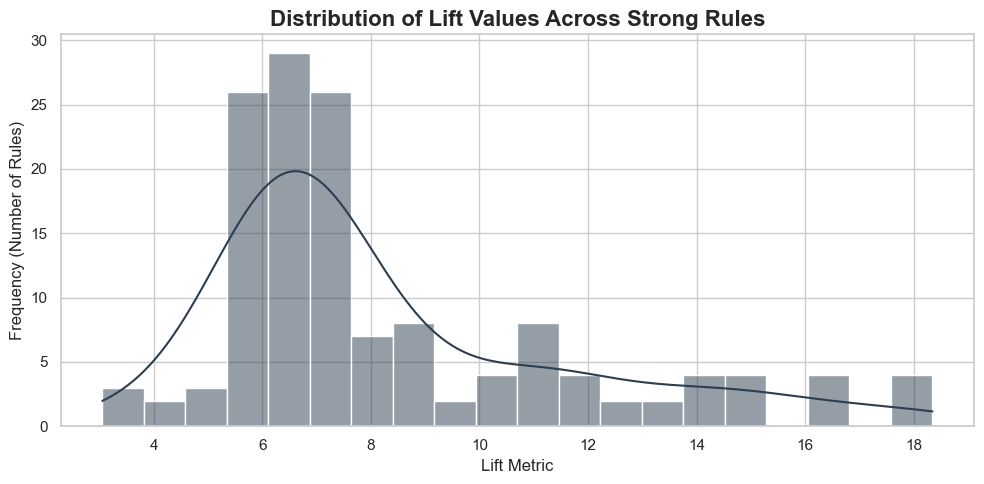

In [8]:
# =============================================================================
# 5.3 HISTOGRAM: DISTRIBUTION OF LIFT VALUES
# =============================================================================

plt.figure(figsize=(10, 5))

sns.histplot(strong_rules['lift'], bins=20, kde=True, color="#2c3e50")

plt.title("Distribution of Lift Values Across Strong Rules", fontsize=16, fontweight="bold")
plt.xlabel("Lift Metric", fontsize=12)
plt.ylabel("Frequency (Number of Rules)", fontsize=12)
plt.tight_layout()
plt.show()

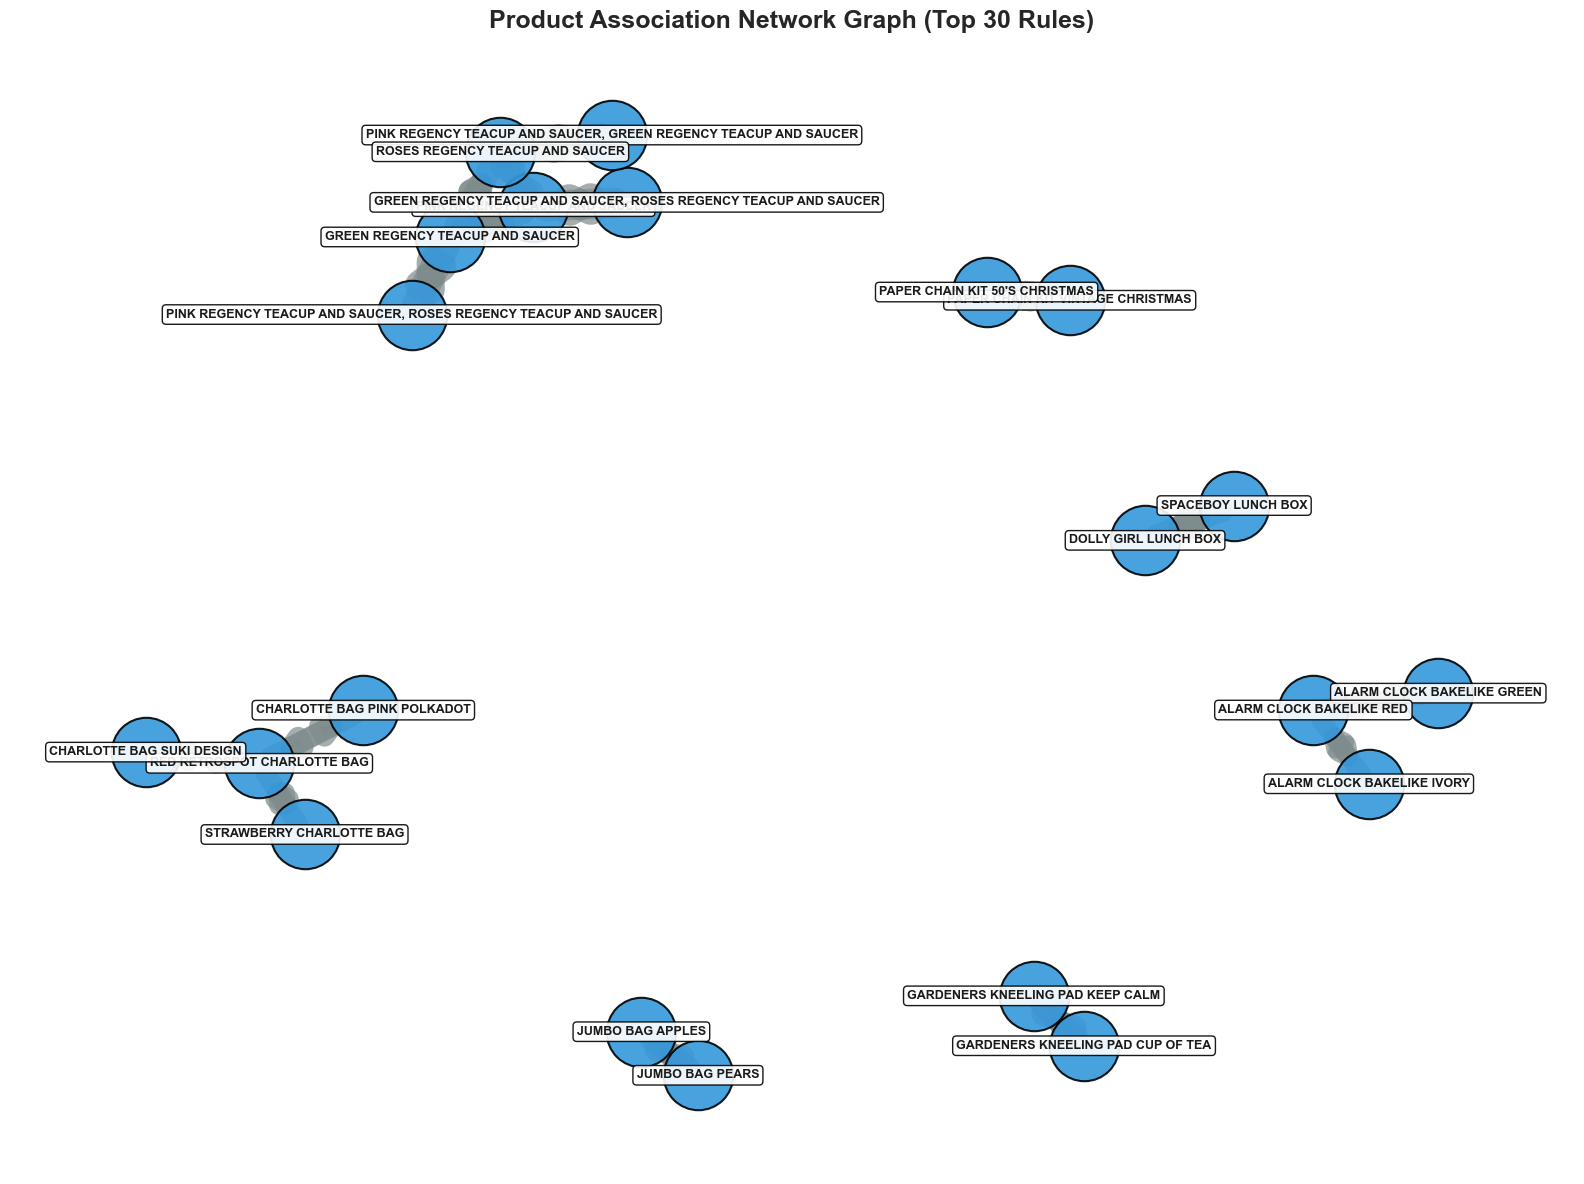

In [9]:
# =============================================================================
# 5.4 NETWORK GRAPH: PRODUCT CLUSTERS
# =============================================================================

# For visual clarity, limit the network graph to the Top 30 strongest rules
top_network_rules = strong_rules.head(30)

G = nx.DiGraph()

# Add edges to the graph
for _, row in top_network_rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['lift'])

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.8, seed=42)

# Draw Nodes
nx.draw_networkx_nodes(
    G, pos, 
    node_size=2500, 
    node_color="#3498db", 
    edgecolors="black", 
    linewidths=1.5, 
    alpha=0.9
)

# Draw Edges (Thicker edges = higher lift)
edges = G.edges()
weights = [G[u][v]['weight'] * 1.2 for u, v in edges]
nx.draw_networkx_edges(
    G, pos, 
    edgelist=edges, 
    width=weights, 
    edge_color="#7f8c8d", 
    arrowsize=20, 
    alpha=0.7
)

# Draw Text Labels
nx.draw_networkx_labels(
    G, pos, 
    font_size=9, 
    font_family="sans-serif", 
    font_weight="bold", 
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=0.9)
)

plt.title("Product Association Network Graph (Top 30 Rules)", fontsize=18, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

---
## 🎯 Phase 3 Conclusion & Business Recommendations

The Apriori algorithm successfully translated 17,500+ raw transactions into highly predictive product associations. 

### Key Business Insights:
1. **High-Confidence Bundles:** Products with a Confidence $> 0.5$ indicate that over 50% of the time the base product is bought, the consequent product is also bought. These are prime candidates for **hard bundling** (selling together as a single SKU at a slight discount).
2. **High-Lift Cross-Sells:** Products with a high Lift metric are heavily dependent on each other. If a customer adds the antecedent to their online cart, the consequent should be immediately triggered in a **"Frequently Bought Together"** recommendation engine.
3. **Store Layout Optimization:** The Network Graph reveals distinct product clusters (e.g., specific design themes like the Regency Tea Sets, or functional pairs like Jumbo Bags). In physical retail, these clusters should be merchandised on the same endcap or in adjacent aisles to reduce purchase friction.

### Project Finalization
The data pipeline is now complete:
* **Phase 1:** Discovered foundational data quality issues and behavioral trends.
* **Phase 2:** Engineered a clean, mathematical boolean matrix.
* **Phase 3:** Mined the matrix to deploy enterprise-grade Association Rules and Visualizations.

These findings directly support the final deliverables and business impact presentations outlined in the project roadmap.